# Imports

In [22]:
import cv2
import numpy as np
from os.path import join
import matplotlib.pyplot as plt
import pandas as pd

# Utils

In [25]:
def displayImage(img):
    # If image has 2 dimensions → grayscale
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    # If image has 3 dimensions → color
    elif len(img.shape) == 3:
        # Convert from OpenCV BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)

    plt.show()

def displayListOfImagesHorizontally(img_list):
    num_images = len(img_list)
    # Create 1 row, N columns
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*3, 3))  # adjust width per image

    # Ensure axes is always a list
    if num_images == 1:
        axes = [axes]

    for ax, img in zip(axes, img_list):
        # If image has 2 dimensions → grayscale
        if len(img.shape) == 2:
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        # If image has 3 dimensions → color
        elif len(img.shape) == 3:
            # Convert from OpenCV BGR to RGB
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
    
    plt.tight_layout()
    plt.show()

# Reading and Resizing

Original


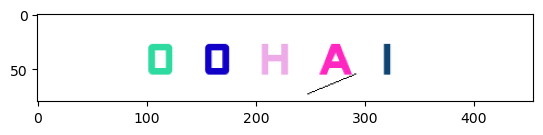

Resized


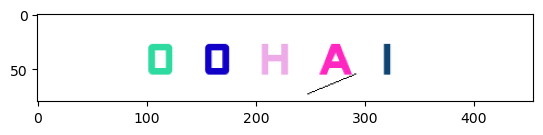

In [28]:
img = cv2.imread('../train/00hai-0.png');
# img = cv2.imread('../train/0duo1r-0.png');
# img = cv2.imread('../train/0kxu0w-0.png');

print("Original")
displayImage(img)

# Resizing To Consistent Height (80px)
h, w, c = img.shape
aspect_ratio = w/h
target_height = 80
target_width = int(target_height * aspect_ratio)

img = cv2.resize(img, (target_width, target_height), interpolation=cv2.INTER_CUBIC)
print("Resized")
displayImage(img)

# Get sorted list of colors

In [31]:
pixels_list = img.reshape(-1, 3) # Get list of pixels

# Use numpy to find the counts of each colors
colors, counts = np.unique(pixels_list, axis=0, return_counts=True)
# Sort colors by counts (descending order)
sorted_indices = np.argsort(-counts)  # add minus for descending
sorted_colors = colors[sorted_indices]
sorted_counts = counts[sorted_indices]

sorted_ratios = sorted_counts.astype(np.float32) / np.sum(sorted_counts)

### Threshold by significant pixel ratios + max number of characters

In [34]:
# By removing colors that only have a few pixels, we can remove some noise
min_pixel_ratio = 0.00001
max_character_count = 20

# Threshold by pixel ratio
mask = sorted_ratios > min_pixel_ratio
filtered_colors = sorted_colors[mask]
filtered_ratios = sorted_ratios[mask]

# Threshold by character count (top character count + 2 most common colors)
filtered_colors = filtered_colors[0: max_character_count + 2]
filtered_ratios = filtered_ratios[0: max_character_count + 2]

print("Significant Colors:")
print(filtered_colors)

Significant Colors:
[[255 255 255]
 [160 218  46]
 [200   0  16]
 [192  39 255]
 [232 172 237]
 [115  69  16]
 [237 189 241]
 [250 238 251]
 [  0   0   0]
 [179 225  88]
 [236 247 212]
 [244 203 206]
 [211  51  64]
 [143 106  64]
 [226 217 206]
 [252 245 255]
 [230 169 255]
 [195  49 255]
 [243 213 255]
 [204  81 255]
 [217 125 255]
 [195  50 255]]


# Separate Image into Characters by Colors

Filtered by
[255 255 255]


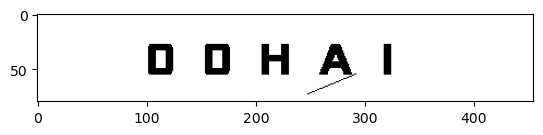

Filtered by
[160 218  46]


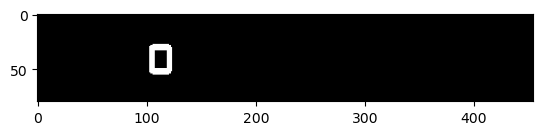

Filtered by
[200   0  16]


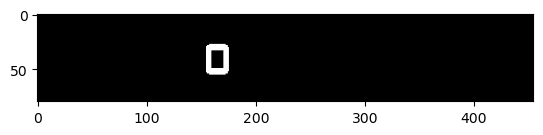

Filtered by
[192  39 255]


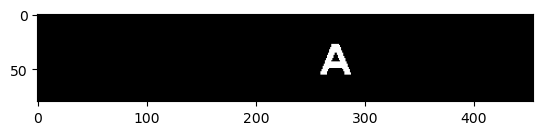

Filtered by
[232 172 237]


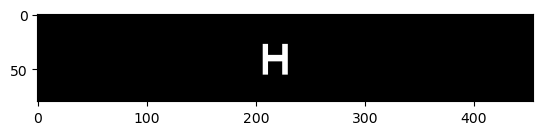

Filtered by
[115  69  16]


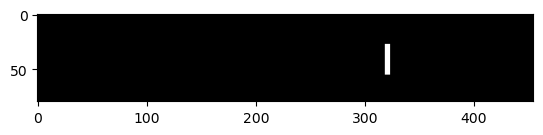

Filtered by
[237 189 241]


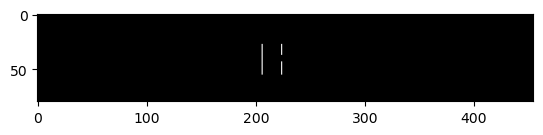

Filtered by
[250 238 251]


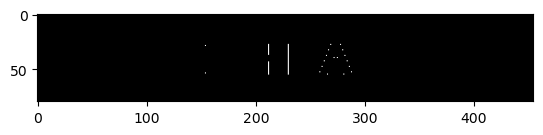

Filtered by
[0 0 0]


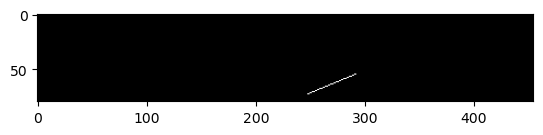

Filtered by
[179 225  88]


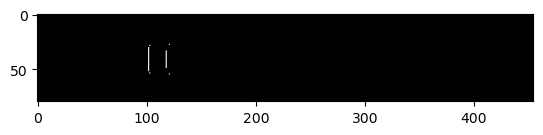

Filtered by
[236 247 212]


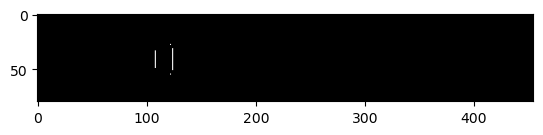

Filtered by
[244 203 206]


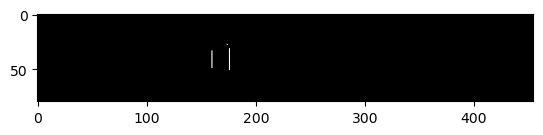

Filtered by
[211  51  64]


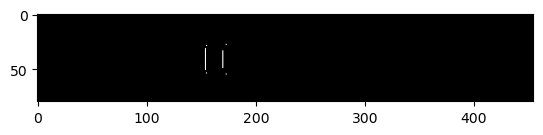

Filtered by
[143 106  64]


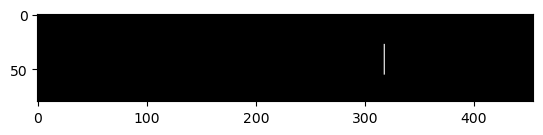

Filtered by
[226 217 206]


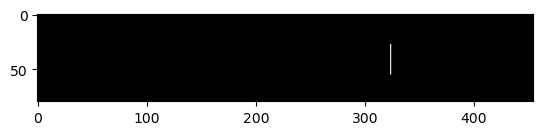

Filtered by
[252 245 255]


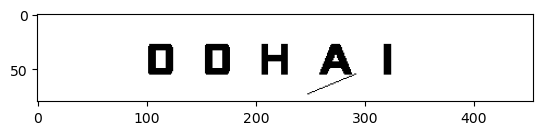

Filtered by
[230 169 255]


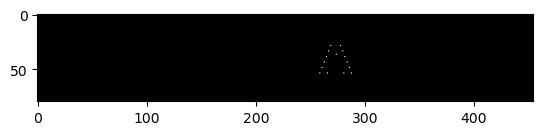

Filtered by
[195  49 255]


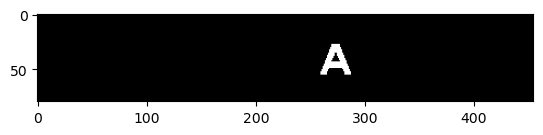

Filtered by
[243 213 255]


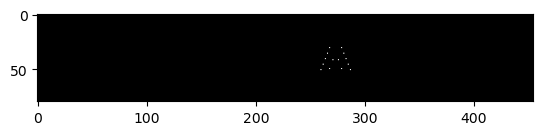

Filtered by
[204  81 255]


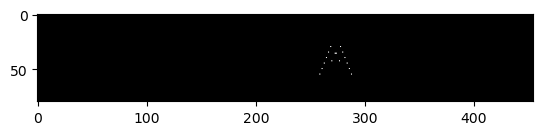

Filtered by
[217 125 255]


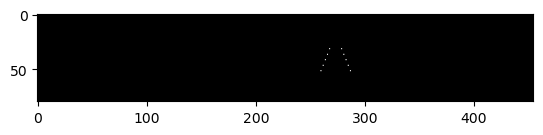

Filtered by
[195  50 255]


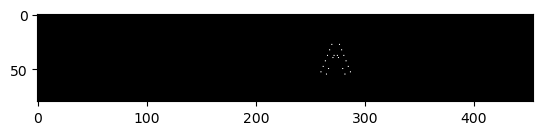

In [39]:
masked_images = []
color_tolerance = 10 #Some tolerance can be useful for noise / blur resistance

for color in filtered_colors:
    lower_color = np.clip(color.astype(np.int32) - color_tolerance, 0, 255).astype(np.uint8)
    upper_color = np.clip(color.astype(np.int32) + color_tolerance, 0, 255).astype(np.uint8)

    mask = cv2.inRange(img, lower_color, upper_color)

    print("Filtered by")
    print(color)
    displayImage(mask)

    masked_images.append(mask)

### Crop to bounding box (also record x)

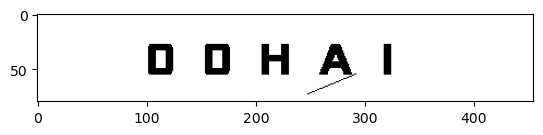

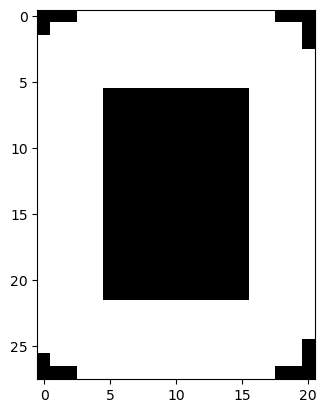

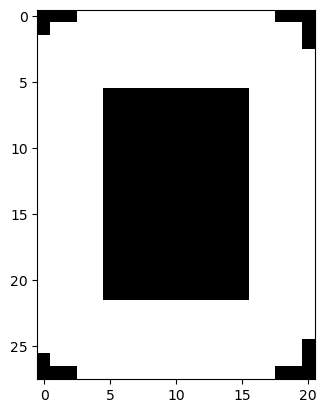

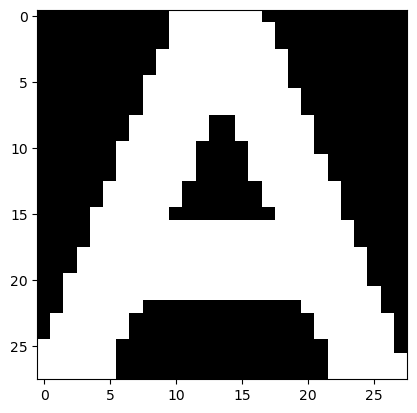

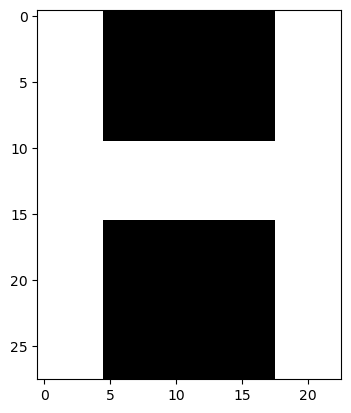

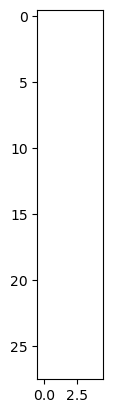

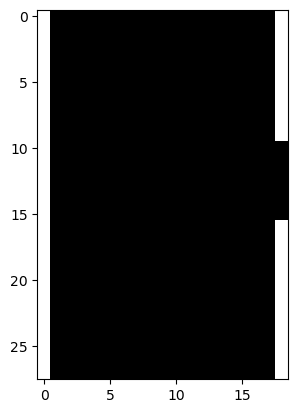

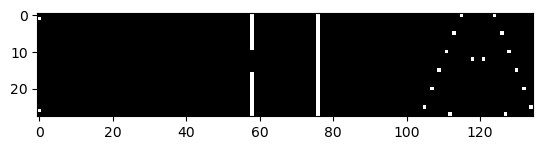

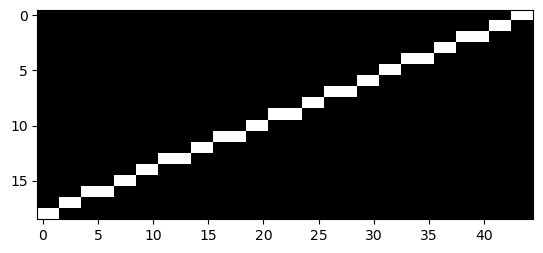

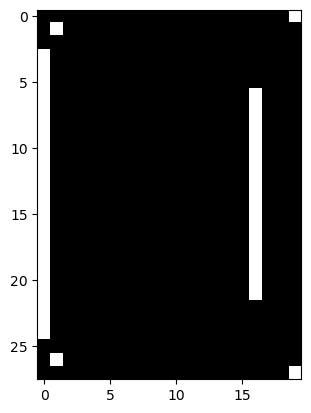

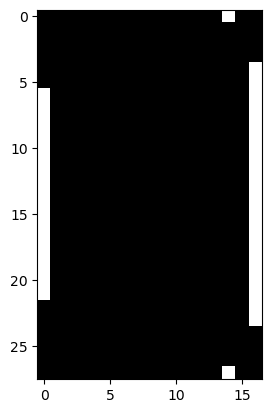

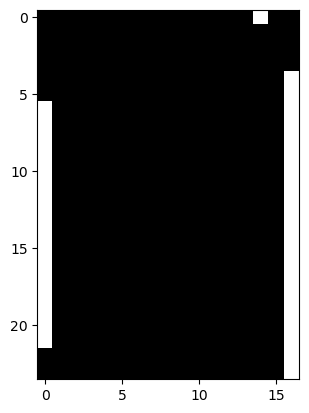

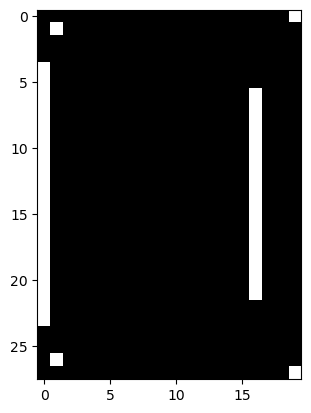

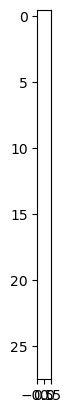

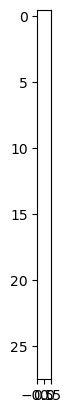

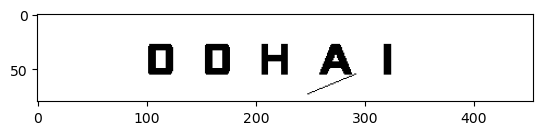

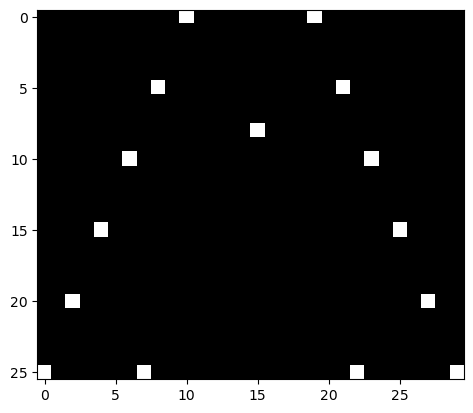

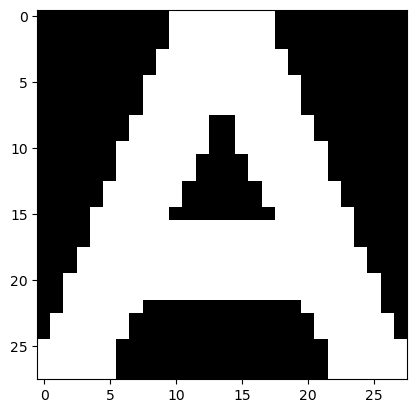

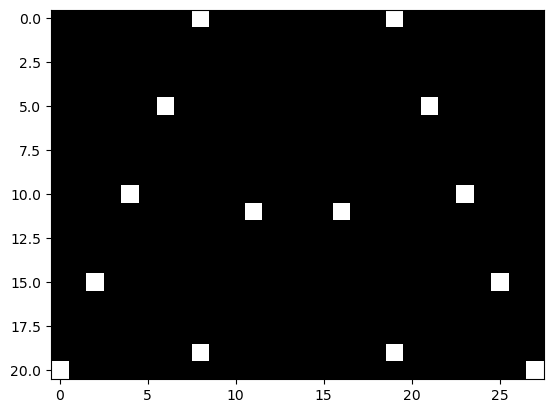

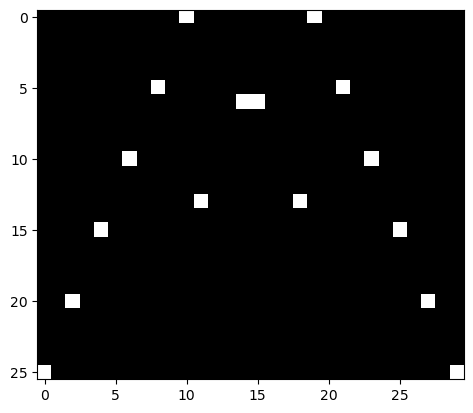

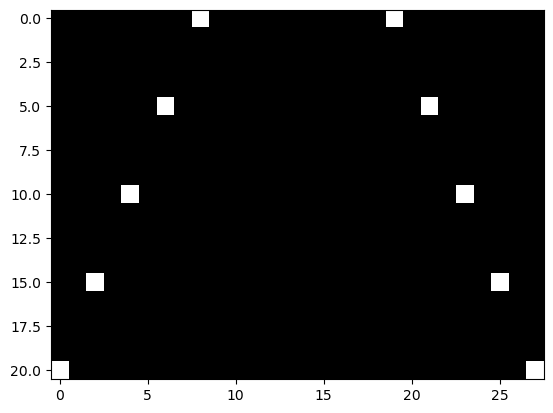

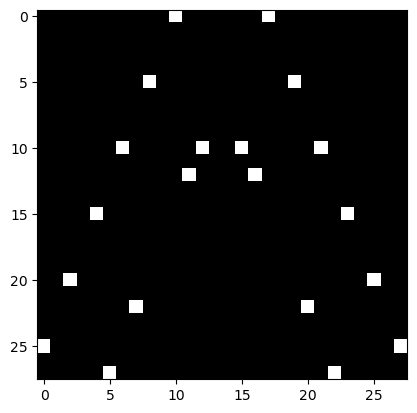

In [42]:
cropped_masked_images = []
cropped_masked_images_positions = []

for img in masked_images:
    # Find all nonzero (white) pixels
    coords = cv2.findNonZero(img)  # returns Nx1x2 array of points
    # Get bounding rectangle of all white pixels
    x, y, w, h = cv2.boundingRect(coords)
    # Crop the original image or mask
    cropped = img[y:y+h, x:x+w]
    displayImage(cropped)

    cropped_masked_images.append(cropped)
    cropped_masked_images_positions.append(x)

### Arrange by X position

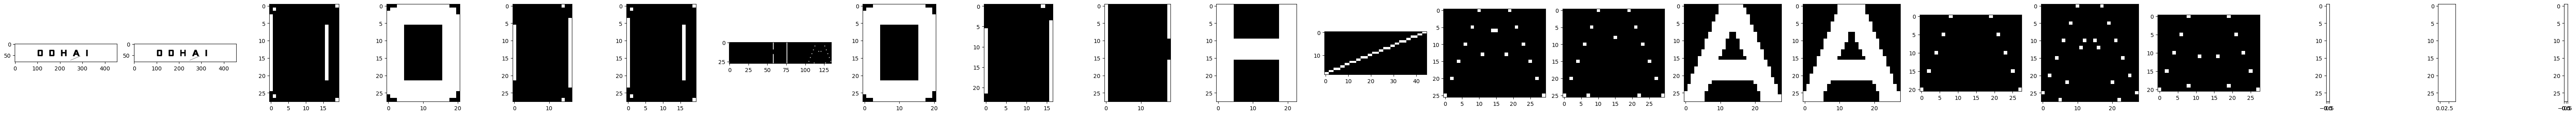

In [45]:
character_images = []

# Sort images by x (ascending order)
sorted_indices = np.argsort(np.array(cropped_masked_images_positions))
character_images = [(cropped_masked_images[i], cropped_masked_images_positions[i]) for i in sorted_indices]

displayListOfImagesHorizontally(list(img for img, _ in character_images))

### Filter out unlikely letters

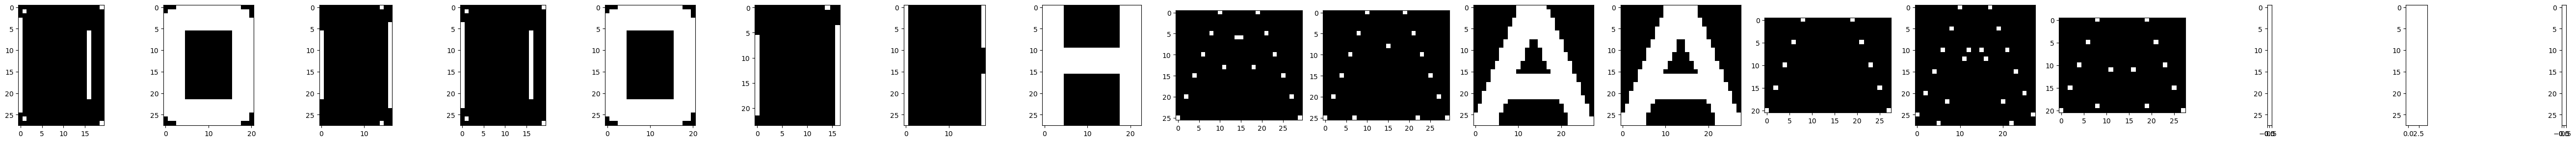

[102, 103, 108, 154, 155, 160, 206, 207, 259, 259, 260, 260, 260, 260, 260, 318, 319, 324]


In [48]:
max_acceptable_xy_ratio = 1.5
min_pixel_height_required = 10

# Filter by ratio
character_images = list(filter(lambda tuple: (tuple[0].shape[1] / tuple[0].shape[0]) <= max_acceptable_xy_ratio, character_images))
# Filter by height
character_images = list(filter(lambda tuple: tuple[0].shape[0] >= min_pixel_height_required, character_images))

displayListOfImagesHorizontally(list(img for img, _ in character_images))
print(list(x for _, x in character_images))